# 05a — model_offered

**Task:** Predict whether a course will be offered in a given term (binary classifier)

**Target:** `was_offered` (0 = not offered, 1 = offered)

**Models tested:**
1. Baseline — always predict majority class
2. Logistic Regression
3. K-Nearest Neighbours
4. Random Forest
5. Gradient Boosting

**Selection metric:** AUC-ROC on test set

**Figures saved to:** `notebooks/figures/05a/`

## 0. Setup

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)
from sklearn.calibration import CalibrationDisplay

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('../figures/05a_model_offered')
FIG_PATH.mkdir(parents=True, exist_ok=True)

assert (DATA_PATH / '04_train.csv').exists(),        'run 04 first'
assert (MODELS_PATH / 'feature_sets.json').exists(), 'run 04 first'
print('ready')

ready


## 1. Load data and define X, y

In [2]:
# unscaled — for RF and GBM
train = pd.read_csv(DATA_PATH / '04_train.csv')
test  = pd.read_csv(DATA_PATH / '04_test.csv')

# scaled — for LR and KNN
train_s = pd.read_csv(DATA_PATH / '04_train_scaled.csv')
test_s  = pd.read_csv(DATA_PATH / '04_test_scaled.csv')

# feature list
with open(MODELS_PATH / 'feature_sets.json') as f:
    FEATURES = json.load(f)['model_offered']

TARGET = 'was_offered'

X_train   = train[FEATURES];   y_train = train[TARGET]
X_test    = test[FEATURES];    y_test  = test[TARGET]
X_train_s = train_s[FEATURES]; 
X_test_s  = test_s[FEATURES]

print(f'X_train: {X_train.shape}  positive rate: {y_train.mean()*100:.1f}%')
print(f'X_test:  {X_test.shape}   positive rate: {y_test.mean()*100:.1f}%')
print(f'features: {len(FEATURES)}')

X_train: (47760, 26)  positive rate: 41.4%
X_test:  (9552, 26)   positive rate: 45.1%
features: 26


## 2. Helper functions

In [3]:
def evaluate_classifier(name, y_true, y_pred, y_prob):
    """Return a dict of metrics for one model."""
    return {
        'model':     name,
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'auc':       round(roc_auc_score(y_true, y_prob), 4),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not offered','Offered'],
                yticklabels=['Not offered','Offered'],
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontsize=11, fontweight='500')

def plot_roc(ax, y_true, y_prob, label, color):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{label}  AUC={auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)

results = []  # collect all model metrics here
print('helpers defined')

helpers defined


## 3. Baseline — always predict majority class

In [4]:
majority_class = int(y_train.mode()[0])
y_base_pred = np.full(len(y_test), majority_class)
# baseline has no probability — use constant 0.5 for AUC
y_base_prob = np.full(len(y_test), y_train.mean())

base_metrics = evaluate_classifier('Baseline', y_test, y_base_pred, y_base_prob)
results.append(base_metrics)

print(f'Baseline always predicts: {majority_class}')
print(f'Baseline accuracy: {base_metrics["accuracy"]}')
print(f'Baseline AUC:      {base_metrics["auc"]}')
print()
print('Every model must beat this AUC to be useful.')

Baseline always predicts: 0
Baseline accuracy: 0.5492
Baseline AUC:      0.5

Every model must beat this AUC to be useful.


## 4. Logistic Regression

In [5]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_s, y_train)

y_lr_pred = lr.predict(X_test_s)
y_lr_prob = lr.predict_proba(X_test_s)[:, 1]

lr_metrics = evaluate_classifier('Logistic Regression', y_test, y_lr_pred, y_lr_prob)
results.append(lr_metrics)
print(lr_metrics)

{'model': 'Logistic Regression', 'accuracy': 1.0, 'auc': np.float64(1.0), 'f1': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0)}


d:\Projects\SFU_offering_predictor\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


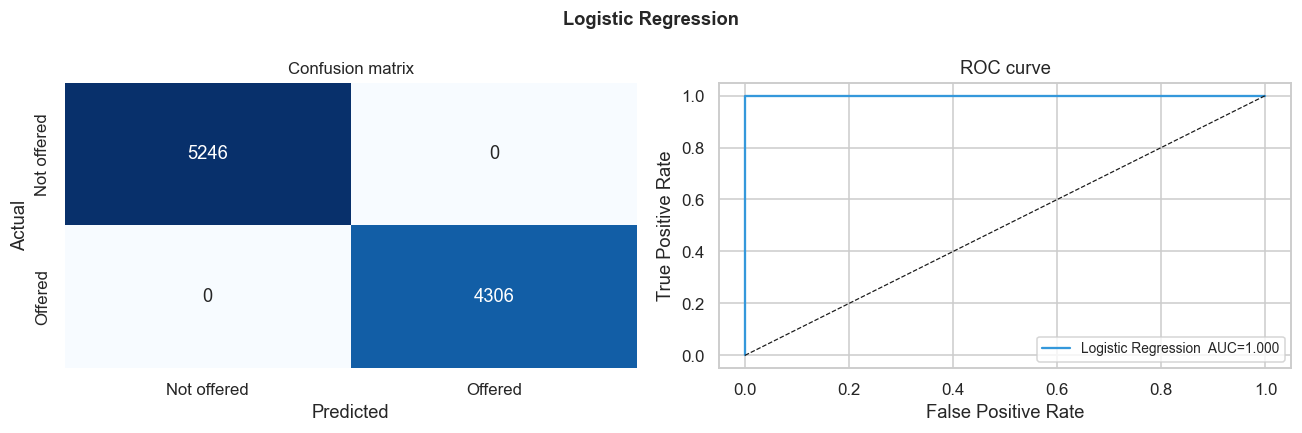

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Logistic Regression', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_lr_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_lr_prob, 'Logistic Regression', '#3498db')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'lr.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. K-Nearest Neighbours

In [7]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_s, y_train)

y_knn_pred = knn.predict(X_test_s)
y_knn_prob = knn.predict_proba(X_test_s)[:, 1]

knn_metrics = evaluate_classifier('KNN', y_test, y_knn_pred, y_knn_prob)
results.append(knn_metrics)
print(knn_metrics)

{'model': 'KNN', 'accuracy': 0.7077, 'auc': np.float64(0.7612), 'f1': np.float64(0.6519), 'precision': np.float64(0.7038), 'recall': np.float64(0.6071)}


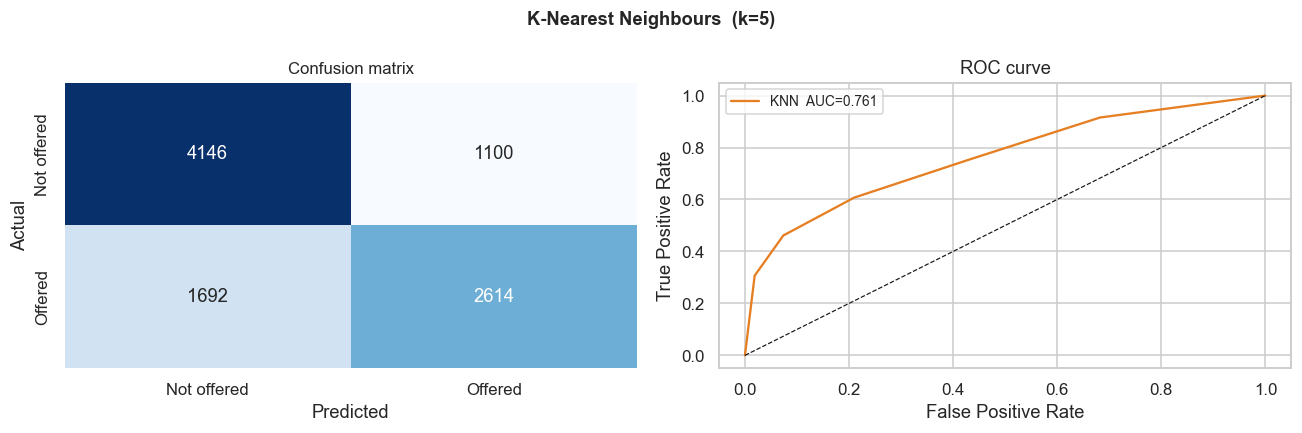

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('K-Nearest Neighbours  (k=5)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_knn_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_knn_prob, 'KNN', '#e67e22')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'knn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_rf_pred = rf.predict(X_test)
y_rf_prob = rf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate_classifier('Random Forest', y_test, y_rf_pred, y_rf_prob)
results.append(rf_metrics)
print(rf_metrics)

{'model': 'Random Forest', 'accuracy': 0.7437, 'auc': np.float64(0.996), 'f1': np.float64(0.7786), 'precision': np.float64(0.6376), 'recall': np.float64(0.9998)}


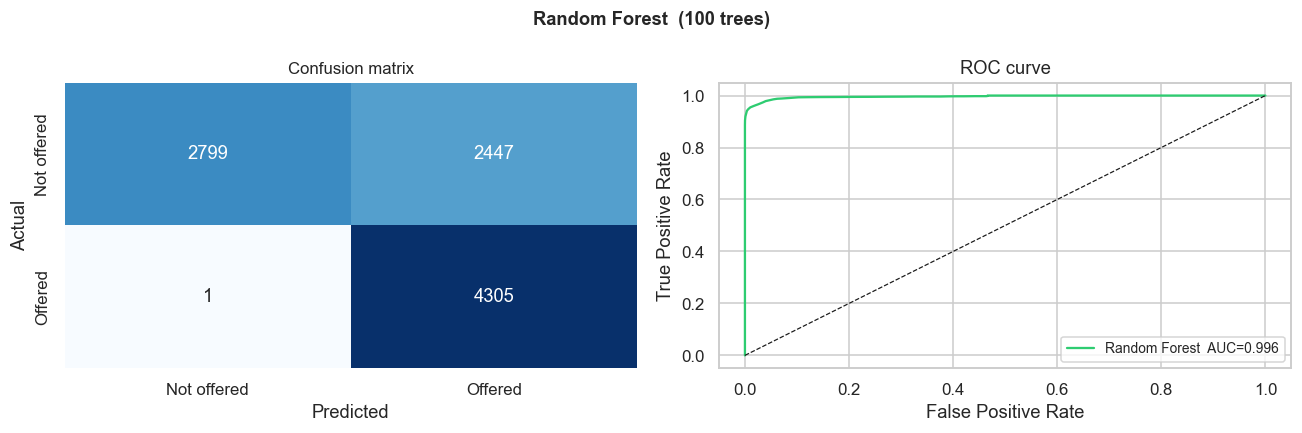

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Random Forest  (100 trees)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_rf_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_rf_prob, 'Random Forest', '#2ecc71')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Gradient Boosting

In [11]:
# handle class imbalance via subsample weighting
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
sample_weights = np.where(y_train == 1, pos_weight, 1.0)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weights)

y_gb_pred = gb.predict(X_test)
y_gb_prob = gb.predict_proba(X_test)[:, 1]

gb_metrics = evaluate_classifier('Gradient Boosting', y_test, y_gb_pred, y_gb_prob)
results.append(gb_metrics)
print(gb_metrics)

{'model': 'Gradient Boosting', 'accuracy': 1.0, 'auc': np.float64(1.0), 'f1': np.float64(1.0), 'precision': np.float64(1.0), 'recall': np.float64(1.0)}


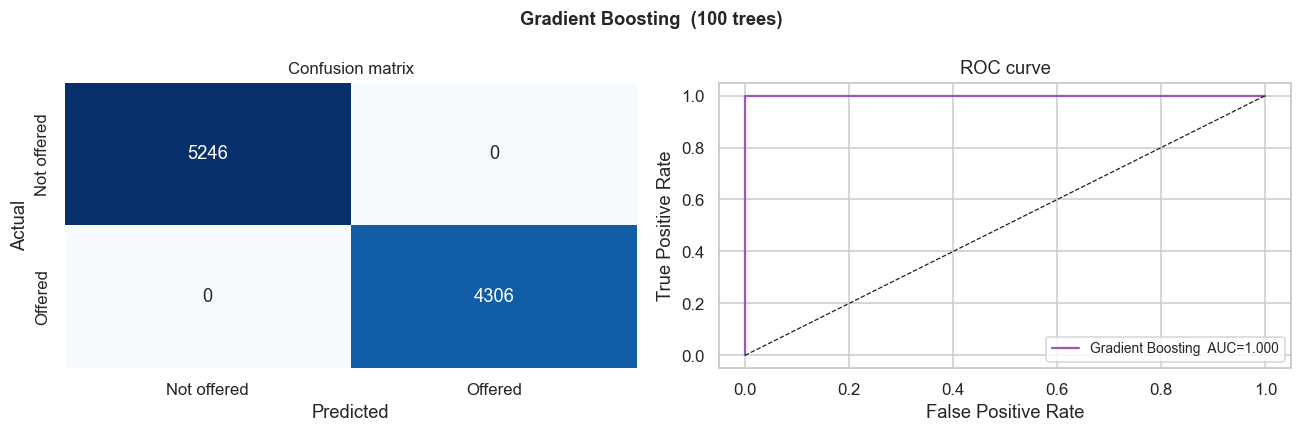

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Gradient Boosting  (100 trees)', fontsize=12, fontweight='bold')
plot_confusion(axes[0], y_test, y_gb_pred, 'Confusion matrix')
plot_roc(axes[1], y_test, y_gb_prob, 'Gradient Boosting', '#9b59b6')
axes[1].set_title('ROC curve')
plt.tight_layout()
plt.savefig(FIG_PATH / 'gb.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparison

In [13]:
results_df = pd.DataFrame(results).set_index('model')
print('=== ALL MODELS ===')
results_df

=== ALL MODELS ===


,accuracy,auc,f1,precision,recall
model,,,,,
Baseline,0.5492,0.5000,0.0000,0.0000,0.0000
Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
KNN,0.7077,0.7612,0.6519,0.7038,0.6071
Random Forest,0.7437,0.9960,0.7786,0.6376,0.9998
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000


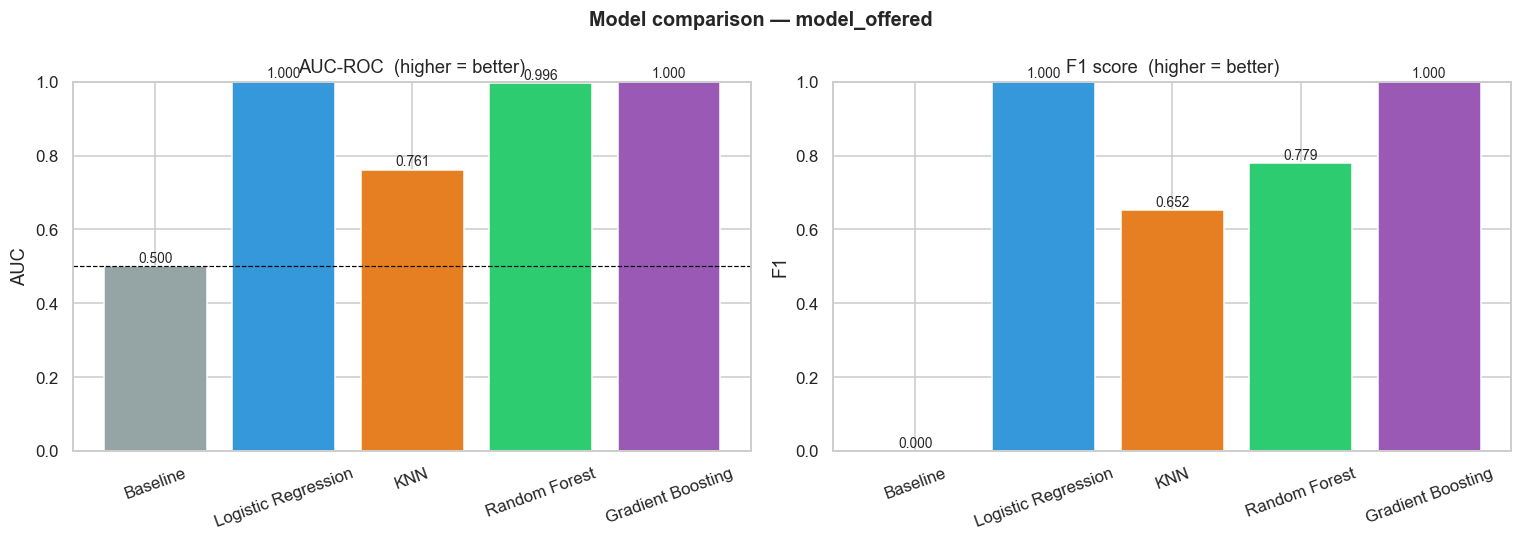

In [14]:
# save results
results_df.to_csv(DATA_PATH / '05a_results.csv')

colors = ['#95a5a6','#3498db','#e67e22','#2ecc71','#9b59b6']
models = results_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model comparison — model_offered', fontsize=13, fontweight='bold')

# AUC comparison
axes[0].bar(models, results_df['auc'], color=colors, edgecolor='white')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=0.8, label='random')
axes[0].set_title('AUC-ROC  (higher = better)')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['auc']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# F1 comparison
axes[1].bar(models, results_df['f1'], color=colors, edgecolor='white')
axes[1].set_title('F1 score  (higher = better)')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(results_df['f1']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / 'comparison.png', dpi=150, bbox_inches='tight')
plt.show()

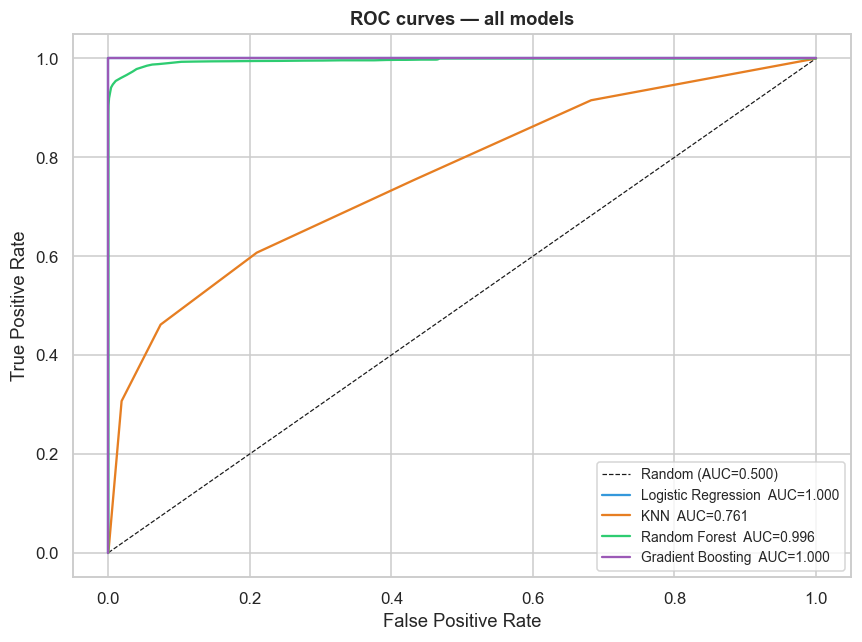

In [15]:
# all 4 ROC curves on one plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.500)')

for (name, y_prob, color) in [
    ('Logistic Regression', y_lr_prob, '#3498db'),
    ('KNN',                 y_knn_prob,'#e67e22'),
    ('Random Forest',       y_rf_prob, '#2ecc71'),
    ('Gradient Boosting',   y_gb_prob, '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{name}  AUC={auc:.3f}')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — all models', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_PATH / 'roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Winner — feature importance + calibration + save

In [16]:
from sklearn.metrics import brier_score_loss

# step 1: find all models tied at the highest AUC
max_auc = results_df['auc'].max()
top_models = results_df[results_df['auc'] == max_auc].index.tolist()
print(f'Max AUC: {max_auc}')
print(f'Models tied at max AUC: {top_models}')
print()

# step 2: compute Brier score for each tied model
# lower Brier = better calibration
prob_map = {
    'Logistic Regression': y_lr_prob,
    'KNN':                 y_knn_prob,
    'Random Forest':       y_rf_prob,
    'Gradient Boosting':   y_gb_prob,
}
model_map = {
    'Logistic Regression': (lr,  X_test_s),
    'KNN':                 (knn, X_test_s),
    'Random Forest':       (rf,  X_test),
    'Gradient Boosting':   (gb,  X_test),
}

brier_scores = {}
for name in top_models:
    brier_scores[name] = round(brier_score_loss(y_test, prob_map[name]), 6)

print('Brier scores for tied models (lower = better calibration):')
for name, score in sorted(brier_scores.items(), key=lambda x: x[1]):
    print(f'  {name}: {score}')
print()

# step 3: pick lowest Brier; alphabetical if still tied
min_brier = min(brier_scores.values())
brier_winners = sorted([n for n, s in brier_scores.items() if s == min_brier])
best_row = brier_winners[0]  # alphabetical tiebreak

best_model, best_X_test = model_map[best_row]

print(f'Winner: {best_row}')
print(f'  AUC:         {results_df.loc[best_row, "auc"]}')
print(f'  Brier score: {brier_scores[best_row]}')

Max AUC: 1.0
Models tied at max AUC: ['Logistic Regression', 'Gradient Boosting']

Brier scores for tied models (lower = better calibration):
  Gradient Boosting: 4e-05
  Logistic Regression: 8.3e-05

Winner: Gradient Boosting
  AUC:         1.0
  Brier score: 4e-05


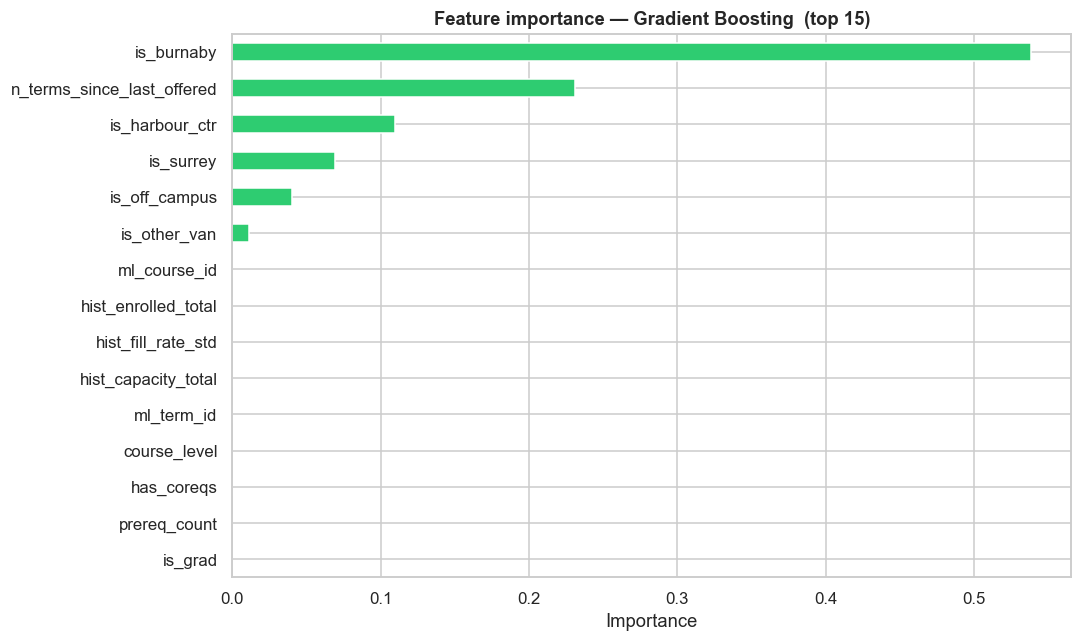

In [17]:
# feature importance — tree models only
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    top15 = importances.nlargest(15).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    top15.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
    ax.set_title(f'Feature importance — {best_row}  (top 15)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIG_PATH / 'winner_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'{best_row} does not have feature_importances_ — skipping importance plot')

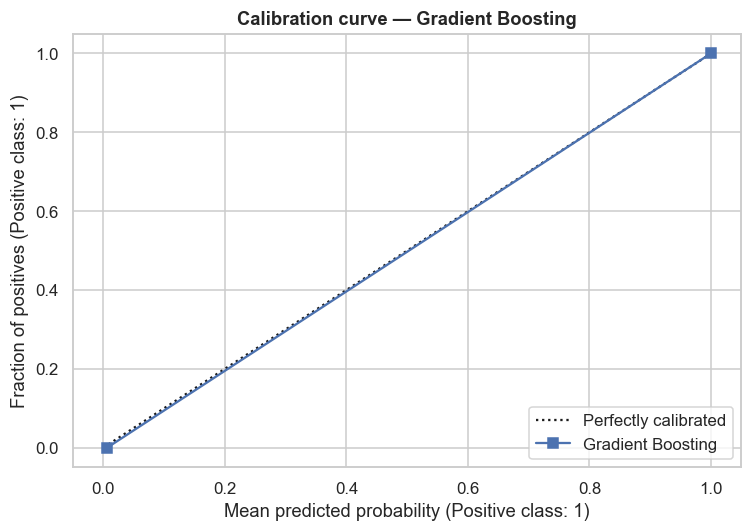

A well-calibrated model has points close to the diagonal.
Points above diagonal = under-predicts probability.
Points below diagonal = over-predicts probability.


In [18]:
# calibration curve — are predicted probabilities trustworthy?
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_estimator(
    best_model, best_X_test, y_test,
    n_bins=10, ax=ax, name=best_row
)
ax.set_title(f'Calibration curve — {best_row}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / 'winner_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('A well-calibrated model has points close to the diagonal.')
print('Points above diagonal = under-predicts probability.')
print('Points below diagonal = over-predicts probability.')

In [19]:
# full classification report for winner
best_pred = best_model.predict(best_X_test)
print(f'--- {best_row} classification report ---')
print(classification_report(y_test, best_pred, target_names=['Not offered','Offered']))

--- Gradient Boosting classification report ---
              precision    recall  f1-score   support

 Not offered       1.00      1.00      1.00      5246
     Offered       1.00      1.00      1.00      4306

    accuracy                           1.00      9552
   macro avg       1.00      1.00      1.00      9552
weighted avg       1.00      1.00      1.00      9552



In [20]:
# save winner
joblib.dump(best_model, MODELS_PATH / 'model_offered.pkl')
print(f'saved: models/model_offered.pkl  ({best_row})')

saved: models/model_offered.pkl  (Gradient Boosting)
